# L22 - N-gram Language Models


---
## 1. Setup — Install / Import Libraries


In [1]:
import math
import random
import collections

try:
    import matplotlib.pyplot as plt

    import nltk
    from nltk.corpus import gutenberg
    from nltk.lm import MLE, Laplace, KneserNeyInterpolated
    from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
    from nltk.util import ngrams
except ImportError as e:
    print(f"LIbraries not installed: {e}")
    print("Installing libraries.")
    %pip install matplotlib nltk


# Download required NLTK data (only needed once)
for resource in ['gutenberg', 'punkt', 'punkt_tab']:
    nltk.download(resource, quiet=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Choose a Text


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
TEXT_ID = 'chesterton-brown.txt'   # <-- change this to try a different text
RANDOM_SEED = 42                   # for reproducibility
# ──────────────────────────────────────────────────────────────────────────────

# Print all available Gutenberg files for reference
print('Available texts in NLTK Gutenberg corpus:')
for fid in gutenberg.fileids():
    words = gutenberg.words(fid)
    sents = gutenberg.sents(fid)
    print(f'  {fid:35s}  {len(words):>7,} words   {len(sents):>5,} sentences')

Available texts in NLTK Gutenberg corpus:
  austen-emma.txt                      192,427 words   7,752 sentences
  austen-persuasion.txt                 98,171 words   3,747 sentences
  austen-sense.txt                     141,576 words   4,999 sentences
  bible-kjv.txt                        1,010,654 words   30,103 sentences
  blake-poems.txt                        8,354 words     438 sentences
  bryant-stories.txt                    55,563 words   2,863 sentences
  burgess-busterbrown.txt               18,963 words   1,054 sentences
  carroll-alice.txt                     34,110 words   1,703 sentences
  chesterton-ball.txt                   96,996 words   4,779 sentences
  chesterton-brown.txt                  86,063 words   3,806 sentences
  chesterton-thursday.txt               69,213 words   3,742 sentences
  edgeworth-parents.txt                210,663 words   10,230 sentences
  melville-moby_dick.txt               260,819 words   10,059 sentences
  milton-paradise.txt         

---
## 3. Explore the Text


In [3]:
raw_text = gutenberg.raw(TEXT_ID)
all_sents = list(gutenberg.sents(TEXT_ID))

print(f'Text: {TEXT_ID}')
print(f'Total characters : {len(raw_text):,}')
print(f'Total sentences  : {len(all_sents):,}')
print(f'Total words      : {len(gutenberg.words(TEXT_ID)):,}')
print()
print('── First 500 characters ──────────────────────────────────────────────────')
print(raw_text[:500])
print('...')

Text: chesterton-brown.txt
Total characters : 406,629
Total sentences  : 3,806
Total words      : 86,063

── First 500 characters ──────────────────────────────────────────────────
[The Wisdom of Father Brown by G. K. Chesterton 1914]


I. The Absence of Mr Glass


THE consulting-rooms of Dr Orion Hood, the eminent criminologist
and specialist in certain moral disorders, lay along the sea-front
at Scarborough, in a series of very large and well-lighted french windows,
which showed the North Sea like one endless outer wall of blue-green marble.
In such a place the sea had something of the monotony of a blue-green dado:
for the chambers themselves were ruled throughout by a 
...


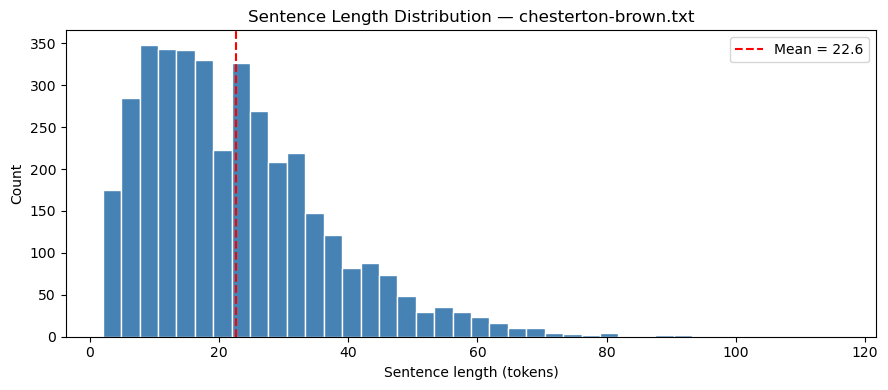

In [4]:
# Sentence length distribution
sent_lengths = [len(s) for s in all_sents]

plt.figure(figsize=(9, 4))
plt.hist(sent_lengths, bins=40, color='steelblue', edgecolor='white')
plt.axvline(x=sum(sent_lengths)/len(sent_lengths), color='red',
            linestyle='--', label=f'Mean = {sum(sent_lengths)/len(sent_lengths):.1f}')
plt.xlabel('Sentence length (tokens)')
plt.ylabel('Count')
plt.title(f'Sentence Length Distribution — {TEXT_ID}')
plt.legend()
plt.tight_layout()
plt.show()

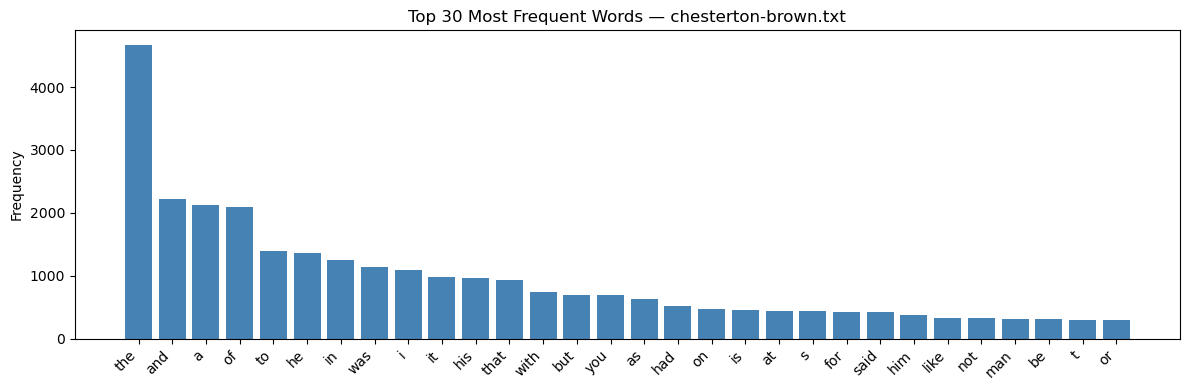

In [5]:
# Top-30 most frequent words (excluding punctuation)
all_tokens = [w.lower() for w in gutenberg.words(TEXT_ID) if w.isalpha()]
freq = collections.Counter(all_tokens)

top_words, top_counts = zip(*freq.most_common(30))

plt.figure(figsize=(12, 4))
plt.bar(top_words, top_counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title(f'Top 30 Most Frequent Words — {TEXT_ID}')
plt.tight_layout()
plt.show()

---
## 4. Preprocessing

In [6]:
def preprocess_sents(sentences):
    """Lowercase every token in every sentence."""
    return [[w.lower() for w in sent] for sent in sentences]

# Train / test split (80 / 20)
split = int(0.8 * len(all_sents))
train_sents = preprocess_sents(all_sents[:split])
test_sents  = preprocess_sents(all_sents[split:])

print(f'Training sentences : {len(train_sents):,}')
print(f'Test sentences     : {len(test_sents):,}')
print()
print('Example training sentence:')
print(train_sents[5])

Training sentences : 3,044
Test sentences     : 762

Example training sentence:
['it', 'must', 'not', 'be', 'supposed', 'that', 'dr', 'hood', "'", 's', 'apartments', 'excluded', 'luxury', ',', 'or', 'even', 'poetry', '.']


---
## 5. Build N-gram Models


In [7]:
# ── Configuration: choose the n values you want to compare ────────────────────
N_VALUES = [1, 2, 3, 4]   # <-- feel free to add 5, 6, ...
# ──────────────────────────────────────────────────────────────────────────────

mle_models = {}   # n -> trained MLE model

for n in N_VALUES:
    train_data, padded_vocab = padded_everygram_pipeline(n, train_sents)
    model = MLE(n)
    model.fit(train_data, padded_vocab)
    mle_models[n] = model
    print(f'n={n}  |  vocab size: {len(model.vocab):,}')

print('\nAll MLE models trained.')

n=1  |  vocab size: 6,959
n=2  |  vocab size: 6,961
n=3  |  vocab size: 6,961
n=4  |  vocab size: 6,961

All MLE models trained.


### 5.1 Inspect Individual Probabilities


In [8]:
# ── Configuration ─────────────────────────────────────────────────────────────
TARGET_WORD = 'father'   # <-- word whose probability we want to inspect
CONTEXT = ('the',)       # <-- context (a tuple of preceding words)
# ──────────────────────────────────────────────────────────────────────────────

print(f"P('{TARGET_WORD}' | context)\n")
for n, model in mle_models.items():
    ctx = CONTEXT[-(n-1):] if n > 1 else []  # trim context to model order
    prob = model.score(TARGET_WORD, ctx)
    print(f'  n={n}, context={list(ctx) if ctx else "(none)"}  ->  P = {prob:.6f}')

P('father' | context)

  n=1, context=(none)  ->  P = 0.002739
  n=2, context=['the']  ->  P = 0.000790
  n=3, context=['the']  ->  P = 0.000790
  n=4, context=['the']  ->  P = 0.000790


---
## 6. Text Generation

In [9]:
def generate_text(model, num_words=40, text_seed=None, random_seed=RANDOM_SEED):
    """Generate a sentence from an NLTK n-gram model.

    Parameters
    ----------
    model       : trained NLTK language model
    num_words   : maximum number of tokens to generate
    text_seed   : optional list of seed tokens
    random_seed : integer seed for reproducibility
    """
    tokens = model.generate(num_words, text_seed=text_seed, random_seed=random_seed)
    # Keep only content tokens (drop padding markers)
    content = [t for t in tokens if t not in ('<s>', '</s>')]
    return ' '.join(content)


# ── Configuration ─────────────────────────────────────────────────────────────
SEED_WORD   = ["her", "mask"]   # starting word(s) as a list, e.g. ['the'] — or None for free generation. use lower case!
GEN_LENGTH  = 30     # how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

print('Generated text for each n-gram order')
print('=' * 70)
for n, model in mle_models.items():
    seed = [SEED_WORD] if isinstance(SEED_WORD, str) else SEED_WORD
    text = generate_text(model, num_words=GEN_LENGTH, text_seed=seed)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'\n[{label}]')
    print(text)

Generated text for each n-gram order

[Unigram]
of ' brown anybody see peering to - handsome ', and in ' and on large announced morbid the " that race down a when domestic -- . the nature

[Bigram]
fell , been consulted by the time , from a family curse , and screaming in black hedge he ' t support , and whispering , and as this occasion

[Trigram]
fell , and for the poor young people , but growing thick and healthy ; his dark clothes had nothing to hide ."

[4-gram]
fell , and the priest were still dawdling about the garden on his hands and knees , still looking at the table , and went across to captain cutler and


### 6.1 Interactive Generation — Change the Seed

In [10]:
# ── Try your own seed ─────────────────────────────────────────────────────────
MY_SEED   = ['the', 'priest']   # <-- change this
MY_N      = 3                   # <-- which model to use
MY_LENGTH = 25                  # <-- how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

if MY_N not in mle_models:
    print(f'Model for n={MY_N} not trained. Add {MY_N} to N_VALUES and re-run cell 5.')
else:
    text = generate_text(mle_models[MY_N], num_words=MY_LENGTH, text_seed=MY_SEED)
    print(f'Seed: {MY_SEED}')
    print(f'Generated ({MY_N}-gram): {" ".join(MY_SEED)} {text}')

Seed: ['the', 'priest']
Generated (3-gram): the priest made a mistake .


---
## 7. Perplexity — Quantitative Evaluation


In [21]:
# Train Laplace-smoothed models for evaluation
laplace_models = {}

for n in N_VALUES:
    train_data, padded_vocab = padded_everygram_pipeline(n, train_sents)
    model = Laplace(n)
    model.fit(train_data, padded_vocab)
    laplace_models[n] = model

print('Laplace models trained.')

Laplace models trained.


In [22]:
def compute_perplexity(model, n, sentences, max_sents=200):
    """Compute average per-sentence perplexity on a list of tokenised sentences.

    Parameters
    ----------
    model     : trained NLTK language model with .perplexity()
    n         : order of the model
    sentences : list of tokenised sentences (list of lists)
    max_sents : cap the number of sentences to keep computation fast
    """
    perplexities = []
    for sent in sentences[:max_sents]:
        test_ngrams = list(ngrams(list(pad_both_ends(sent, n=n)), n))
        if not test_ngrams:
            continue
        pp = model.perplexity(test_ngrams)
        if math.isfinite(pp):
            perplexities.append(pp)
    return sum(perplexities) / len(perplexities) if perplexities else float('nan')


print(f"{'n':>4}  {'Model':12}  {'Train PP':>10}  {'Test PP':>10}")
print('-' * 44)

train_pps, test_pps = [], []

for n in N_VALUES:
    model = laplace_models[n]
    train_pp = compute_perplexity(model, n, train_sents)
    test_pp  = compute_perplexity(model, n, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'{n:>4}  {label:12}  {train_pp:>10.2f}  {test_pp:>10.2f}')

   n  Model           Train PP     Test PP
--------------------------------------------
   1  Unigram           615.35      668.00
   2  Bigram            958.26     1303.75
   3  Trigram          1863.34     2879.58
   4  4-gram           2114.31     3441.21


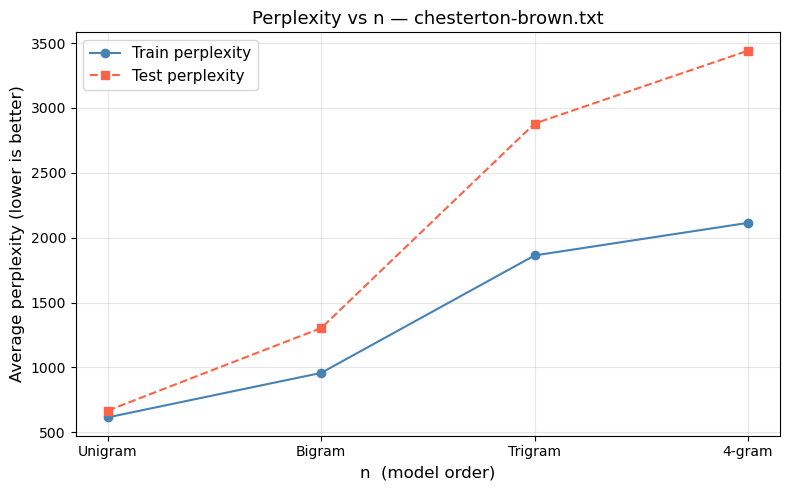

In [13]:
# Plot perplexity vs n
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_VALUES, train_pps, 'o-', label='Train perplexity', color='steelblue')
ax.plot(N_VALUES, test_pps,  's--', label='Test perplexity',  color='tomato')
ax.set_xlabel('n  (model order)', fontsize=12)
ax.set_ylabel('Average perplexity (lower is better)', fontsize=12)
ax.set_title(f'Perplexity vs n — {TEXT_ID}', fontsize=13)
ax.set_xticks(N_VALUES)
ax.set_xticklabels(
    [{1:'Unigram',2:'Bigram',3:'Trigram',4:'4-gram'}.get(n, f'{n}-gram') for n in N_VALUES]
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Exploring Data Sparsity

   n    Test n-grams    Unseen    % unseen
--------------------------------------------
   1           4,242       282        6.6%
   2           4,442     1,842       41.5%
   3           4,642     3,290       70.9%
   4           4,842     3,957       81.7%


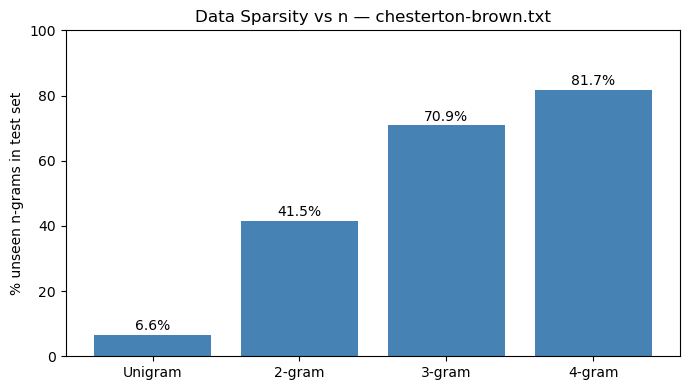

In [14]:
print(f"{'n':>4}  {'Test n-grams':>14}  {'Unseen':>8}  {'% unseen':>10}")
print('-' * 44)

unseen_fractions = []

for n in N_VALUES:
    model = mle_models[n]   # use MLE to expose zero-probability n-grams clearly
    total, unseen = 0, 0
    for sent in test_sents[:200]:
        for gram in ngrams(list(pad_both_ends(sent, n=n)), n):
            total += 1
            if model.score(gram[-1], gram[:-1]) == 0:
                unseen += 1
    fraction = unseen / total if total else 0
    unseen_fractions.append(fraction * 100)
    print(f'{n:>4}  {total:>14,}  {unseen:>8,}  {fraction*100:>9.1f}%')

# Bar chart
plt.figure(figsize=(7, 4))
bars = plt.bar(
    [f'{n}-gram' if n > 1 else 'Unigram' for n in N_VALUES],
    unseen_fractions, color='steelblue'
)
for bar, val in zip(bars, unseen_fractions):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.ylabel('% unseen n-grams in test set')
plt.title(f'Data Sparsity vs n — {TEXT_ID}')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1 — Effect of N on Text Quality

1. In section 5.1: What do you notice in the individual probabilities? Explain why we are getting these probabilities for different n-gram models.
2. Set `SEED_WORD = None` in Section 6 and generate 50 tokens for each n = 1, 2, 3, 4.
3. Read the generated texts. Which model produces the most coherent output? Which the least?
4. Now try `SEED_WORD = 'the'`. How does having a seed change things for each model?

**Observations**

For this exercise, chesterton-brown.txt is used.

1.
The given setup of the target word being "father" and context "the" is used, the code and results are repeated in the first code cell below. The first thing to notice in the individual probabilties is that the individual probability of n=1, is significantly higher than for n=2,3,4 and that the probabilities of n=2,3,4 is equal. The high individual probability of n=1, is because the unigram model ignores the context and is simply printing the overall frequency of the target word in the text. The other models takes the given context into account and estimates how often the target word appears after 1, 2 or 3 of the previous words, but since the context is merely the word "the", considering more than 1 of the previous words does not make a difference. For a longer context, these values would therefore differ.

2.
The code of section 6 is copied and changed to SEED_WORD=None, see exercise 1.2 below. 50 tokes is then generated for each n=1, 2, 3, 4. See results of exercise 1.2 in the code cells below.

3.
The bigram model seems to produce the most coherent longer output capturing some word to word dependencies and recognizable phrases. The unigram is the least coherent because it ignores context and simply samples words according to their overall frequencies. The trigram and 4-gram models also produce locally coherent phrases but they end very quickly, which makes them less usefull for evaluating long terms coherence.

4.
See exercise 1.4 below for implementation. Having a seed does not change anything for the unigram model, it is the exact same text. For the bigram model, only a single word, the first word, is changed from nightmare to poet! which is also a rather small change, only slighly improving the coherence of the sentence. It does, however change a lot for the trigram and 4-gram models which both improve significantly.


In [27]:
# Exercise 1.1
print(f"P('{TARGET_WORD}' | context)\n")
for n, model in mle_models.items():
    ctx = CONTEXT[-(n-1):] if n > 1 else []  # trim context to model order
    prob = model.score(TARGET_WORD, ctx)
    print(f'  n={n}, context={list(ctx) if ctx else "(none)"}  ->  P = {prob:.6f}')

P('father' | context)

  n=1, context=(none)  ->  P = 0.002739
  n=2, context=['the']  ->  P = 0.000790
  n=3, context=['the']  ->  P = 0.000790
  n=4, context=['the']  ->  P = 0.000790


In [30]:
# Exercise 1.2
# ── Configuration ─────────────────────────────────────────────────────────────
SEED_WORD = None   # starting word(s) as a list, e.g. ['the'] — or None for free generation. use lower case!
GEN_LENGTH  = 50     # how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

print('Generated text for each n-gram order')
print('=' * 70)
for n, model in mle_models.items():
    seed = [SEED_WORD] if isinstance(SEED_WORD, str) else SEED_WORD
    text = generate_text(model, num_words=GEN_LENGTH, text_seed=seed)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'\n[{label}]')
    print(text)

Generated text for each n-gram order

[Unigram]
of ' brown anybody see peering to - handsome ', and in ' and on large announced morbid the " that race down a when domestic -- . the nature that saw jacket with first life the occupants the may red , aristocrat call ," as . but of fact

[Bigram]
nightmare . a shade of these black eyes , and more , and screaming in black hedge he ' t support , and whispering , and as this occasion ; it like very like don ' s tale as such a fellow , after a child , nothing but

[Trigram]
marie antoinette .

[4-gram]
land , and over the top of swagger .


In [33]:
# Exercise 1.4
# ── Configuration ─────────────────────────────────────────────────────────────
SEED_WORD = ['the']   # starting word(s) as a list, e.g. ['the'] — or None for free generation. use lower case!
GEN_LENGTH  = 50     # how many tokens to generate
# ──────────────────────────────────────────────────────────────────────────────

print('Generated text for each n-gram order')
print('=' * 70)
for n, model in mle_models.items():
    seed = [SEED_WORD] if isinstance(SEED_WORD, str) else SEED_WORD
    text = generate_text(model, num_words=GEN_LENGTH, text_seed=seed)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'\n[{label}]')
    print(text)

Generated text for each n-gram order

[Unigram]
of ' brown anybody see peering to - handsome ', and in ' and on large announced morbid the " that race down a when domestic -- . the nature that saw jacket with first life the occupants the may red , aristocrat call ," as . but of fact

[Bigram]
poet ! a shade of these black eyes , and more , and screaming in black hedge he ' t support , and whispering , and as this occasion ; it like very like don ' s tale as such a fellow , after a child , nothing but

[Trigram]
poet ' s daughter will be till god sends us braver men .

[4-gram]
poet ' s head like a purple windmill a thing happened which was superficially even more startling .


---

### Exercise 2 — Comparing Texts

1. Repeat the full analysis (Sections 4–8) with **two different texts** from the Gutenberg corpus (e.g. `carroll-alice.txt` and `shakespeare-hamlet.txt`).
2. For both texts, record the test perplexity for n = 1, 2, 3, 4 (Laplace model).
3. Which text gives lower perplexity at each n? Why might that be?

| n | Alice PP | Hamlet PP |
|---|----------|-----------|
| 1 | 458.14 | 596.70 |
| 2 | 471.27 | 884.19 |
| 3 | 870.47 | 1522.95 |
| 4 | 1078.29 | 1745.59 |

**Analysis**

The analysis is performed with both carroll-alice.txt and shakespeare-hamlet.txt. The resulting perplexity is calculated in the code cells below and shown in the table above.

The Alice model gives lower text perplexity than the Hamlet model for every value of n. This means that with the Laplace smoothed n-gram models, the test portion of the Alice test is generally easier to predict for the model than the test portion of Hamlet. This is most likely because the Alice text has a more regular and repetivie pose with simpler sentence structure and vocabulary than the Hamlet text. Shakespear is known for his unique language, which is quite likely a contributor. 

The reason the perplexity tends to increase with n is most likely because of sparsity.

In [47]:
# Exercise 2.1 -carroll-alice.txt perplexity
print(f"{'n':>4}  {'Model':12}  {'Train PP':>10}  {'Test PP':>10}")
print('-' * 44)

train_pps, test_pps = [], []

for n in N_VALUES:
    model = laplace_models[n]
    train_pp = compute_perplexity(model, n, train_sents)
    test_pp  = compute_perplexity(model, n, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'{n:>4}  {label:12}  {train_pp:>10.2f}  {test_pp:>10.2f}')

   n  Model           Train PP     Test PP
--------------------------------------------
   1  Unigram           383.62      458.14
   2  Bigram            348.72      471.27
   3  Trigram           607.00      870.47
   4  4-gram            719.32     1078.29


In [61]:
# Exercise 2.2 - shakespeare-hamlet perplexity
print(f"{'n':>4}  {'Model':12}  {'Train PP':>10}  {'Test PP':>10}")
print('-' * 44)

train_pps, test_pps = [], []

for n in N_VALUES:
    model = laplace_models[n]
    train_pp = compute_perplexity(model, n, train_sents)
    test_pp  = compute_perplexity(model, n, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    label = {1: 'Unigram', 2: 'Bigram', 3: 'Trigram', 4: '4-gram'}.get(n, f'{n}-gram')
    print(f'{n:>4}  {label:12}  {train_pp:>10.2f}  {test_pp:>10.2f}')

   n  Model           Train PP     Test PP
--------------------------------------------
   1  Unigram           436.01      596.70
   2  Bigram            526.69      884.19
   3  Trigram           827.75     1522.95
   4  4-gram            909.23     1745.59


---

### Exercise 3 — Training Data Size

Data sparsity worsens when training data is small.  
Using your chosen text, train the **trigram Laplace model** on three different-sized training sets>
* 10% of sentences  
* 50% of sentences  
* 80% of sentences  

For each, compute the test perplexity and the % of unseen n-grams. What trend do you observe?

| Training fraction | Test perplexity | % unseen trigrams |
|-------------------|-----------------|-------------------|
| 10% | 4211.08 | 84.3% |
| 50% | 3214.71 | 75.1% |
| 80% | 2879.58 | 70.9% |

**Analysis**

The training of the trigram Laplace model on the three different sized training sets is performed in the code cell below.

It is generally observed that both the the perplexity and the unseen trigrams decreases with the increase of training data. This is also what would be expected since as the training set becomes larger, the model has seen more trigrams context and therefore suffers less from data sparsity, resulting in a lower perplexity. It should, however, be noted that the above results are for a fixed vocabulary where every model uses the same set of possible words when assigning probabilities. If each model is allowed to build its own vocabulary, the unseen trigrams remains the same, but the results of the test perplexity flips, meaning an increasing trends is instead seen. This occurrs because many test words becomes <UNK> when using a small training set, meaning they are unknown and therefore collapse into one unknown token, making the test set artifically easier. This mainly occurs due to the laplace smoothing. Using a fixed vocabulary then makes the comparison fairer and gives the above results.



In [ ]:
# Exercise 3
TEXT_ID = 'chesterton-brown.txt'
RANDOM_SEED = 42 
N_VALUE=3

all_sents = list(gutenberg.sents(TEXT_ID))

split = int(0.8 * len(all_sents))
train_sents = preprocess_sents(all_sents[:split])
test_sents  = preprocess_sents(all_sents[split:])

from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace, MLE

_, fixed_vocab = padded_everygram_pipeline(N_VALUE, train_sents)
fixed_vocab = list(fixed_vocab)  # consume generator once and reuse


Train_fraction=[0.10, 0.50, 0.80]

laplace_models = {}
unseen_fractions = []
mle_models = {}

for frac in Train_fraction:
    train_size=int(frac * len(all_sents))
    train_subset = train_sents[:train_size]
    
    train_data, padded_vocab = padded_everygram_pipeline(N_VALUE, train_subset)
    model = Laplace(N_VALUE)
    model.fit(train_data, fixed_vocab)
    train_pp = compute_perplexity(model, N_VALUE, train_subset)
    test_pp  = compute_perplexity(model, N_VALUE, test_sents)
    train_pps.append(train_pp)
    test_pps.append(test_pp)
    # MLE model for unseen trigram counting
    train_data_mle, padded_vocab_mle = padded_everygram_pipeline(N_VALUE, train_subset)
    mle_model = MLE(N_VALUE)
    mle_model.fit(train_data_mle, fixed_vocab)

    total, unseen = 0, 0

    for sent in test_sents[:200]:
        padded_sent = list(pad_both_ends(sent, n=N_VALUE))

        for gram in ngrams(padded_sent, N_VALUE):
            total += 1

            word = gram[-1]
            context = gram[:-1]

            if mle_model.score(word, context) == 0:
                unseen += 1

    fraction = unseen / total if total else 0
    unseen_fractions.append(fraction * 100)
    print(f"Training fraction={frac:.0%}, sentences={train_size:,}, test PP={test_pp:.2f}, unseen trigrams={fraction*100:.1f}%")


Training fraction=10%, sentences=380, test PP=4211.08, unseen trigrams=84.3%
Training fraction=50%, sentences=1,903, test PP=3214.71, unseen trigrams=75.1%
Training fraction=80%, sentences=3,044, test PP=2879.58, unseen trigrams=70.9%
